# Purchase Seasonality and Weekday Pattern

This notebook tests whether sales follow repeatable weekday and monthly seasonality beyond holiday effects.

## 1. Hypothesis and Setup

**Hypothesis:** Sales follow repeatable weekday and monthly seasonality strong enough to support timing features or demand planning.

**Datasets:**
- `transaction_full_2025.parquet`

**Columns to Inspect:**
- updated_date
- quantity
- customer_id
- item_id

**Plan:**
1. Load data lazily using Polars.
2. Aggregate sales by day, weekday, week, and month.
3. Compare periods across the calendar.
4. Compute seasonal indices by weekday and month.
5. Run Kruskal-Wallis test across weekday groups.
6. Detect outlier days using Z-score.
7. Visualize: daily trend line, weekday boxplots, month-by-weekday heatmap.
8. Decide whether the signal is strong enough to keep.

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

DATA_DIR = Path("../..")
TRANSACTION_FILE = DATA_DIR / "transaction_full_2025.parquet"

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Data

In [2]:
transactions = (
    pl.scan_parquet(TRANSACTION_FILE)
    .select(["customer_id", "item_id", "updated_date", "quantity"])
    .with_columns(
        pl.col("updated_date").dt.truncate("1d").alias("date")
    )
)

print("Lazy data pipeline prepared.")
print(f"Schema: {transactions.collect_schema()}")

Lazy data pipeline prepared.
Schema: Schema({'customer_id': Int32, 'item_id': String, 'updated_date': Datetime(time_unit='us', time_zone=None), 'quantity': Int32, 'date': Datetime(time_unit='us', time_zone=None)})


## 3. Daily Sales Aggregation

Aggregate total quantity sold and number of unique transactions per day.

In [3]:
daily_sales = (
    transactions
    .group_by("date")
    .agg([
        pl.col("quantity").sum().alias("total_qty"),
        pl.len().alias("num_transactions"),
        pl.col("customer_id").n_unique().alias("unique_customers")
    ])
    .sort("date")
).collect()

# Add weekday (1=Mon .. 7=Sun) and month columns
daily_sales = daily_sales.with_columns([
    pl.col("date").dt.weekday().alias("weekday"),
    pl.col("date").dt.month().alias("month"),
    pl.col("date").dt.strftime("%a").alias("weekday_name"),
])

print(f"Daily sales rows: {len(daily_sales)}")
print(f"Date range: {daily_sales['date'].min()} to {daily_sales['date'].max()}")
print(daily_sales.head(10))

Daily sales rows: 332
Date range: 2025-01-01 00:00:00 to 2025-12-01 00:00:00
shape: (10, 7)
┌─────────────────┬───────────┬─────────────────┬─────────────────┬─────────┬───────┬──────────────┐
│ date            ┆ total_qty ┆ num_transaction ┆ unique_customer ┆ weekday ┆ month ┆ weekday_name │
│ ---             ┆ ---       ┆ s               ┆ s               ┆ ---     ┆ ---   ┆ ---          │
│ datetime[μs]    ┆ i32       ┆ ---             ┆ ---             ┆ i8      ┆ i8    ┆ str          │
│                 ┆           ┆ u32             ┆ u32             ┆         ┆       ┆              │
╞═════════════════╪═══════════╪═════════════════╪═════════════════╪═════════╪═══════╪══════════════╡
│ 2025-01-01      ┆ 185001    ┆ 120015          ┆ 44515           ┆ 3       ┆ 1     ┆ Wed          │
│ 00:00:00        ┆           ┆                 ┆                 ┆         ┆       ┆              │
│ 2025-01-02      ┆ 159855    ┆ 100966          ┆ 39141           ┆ 4       ┆ 1     ┆ Thu          │

## 4. Daily Sales Trend Line

A line chart of daily total quantity to visualize overall trends and anomalies.

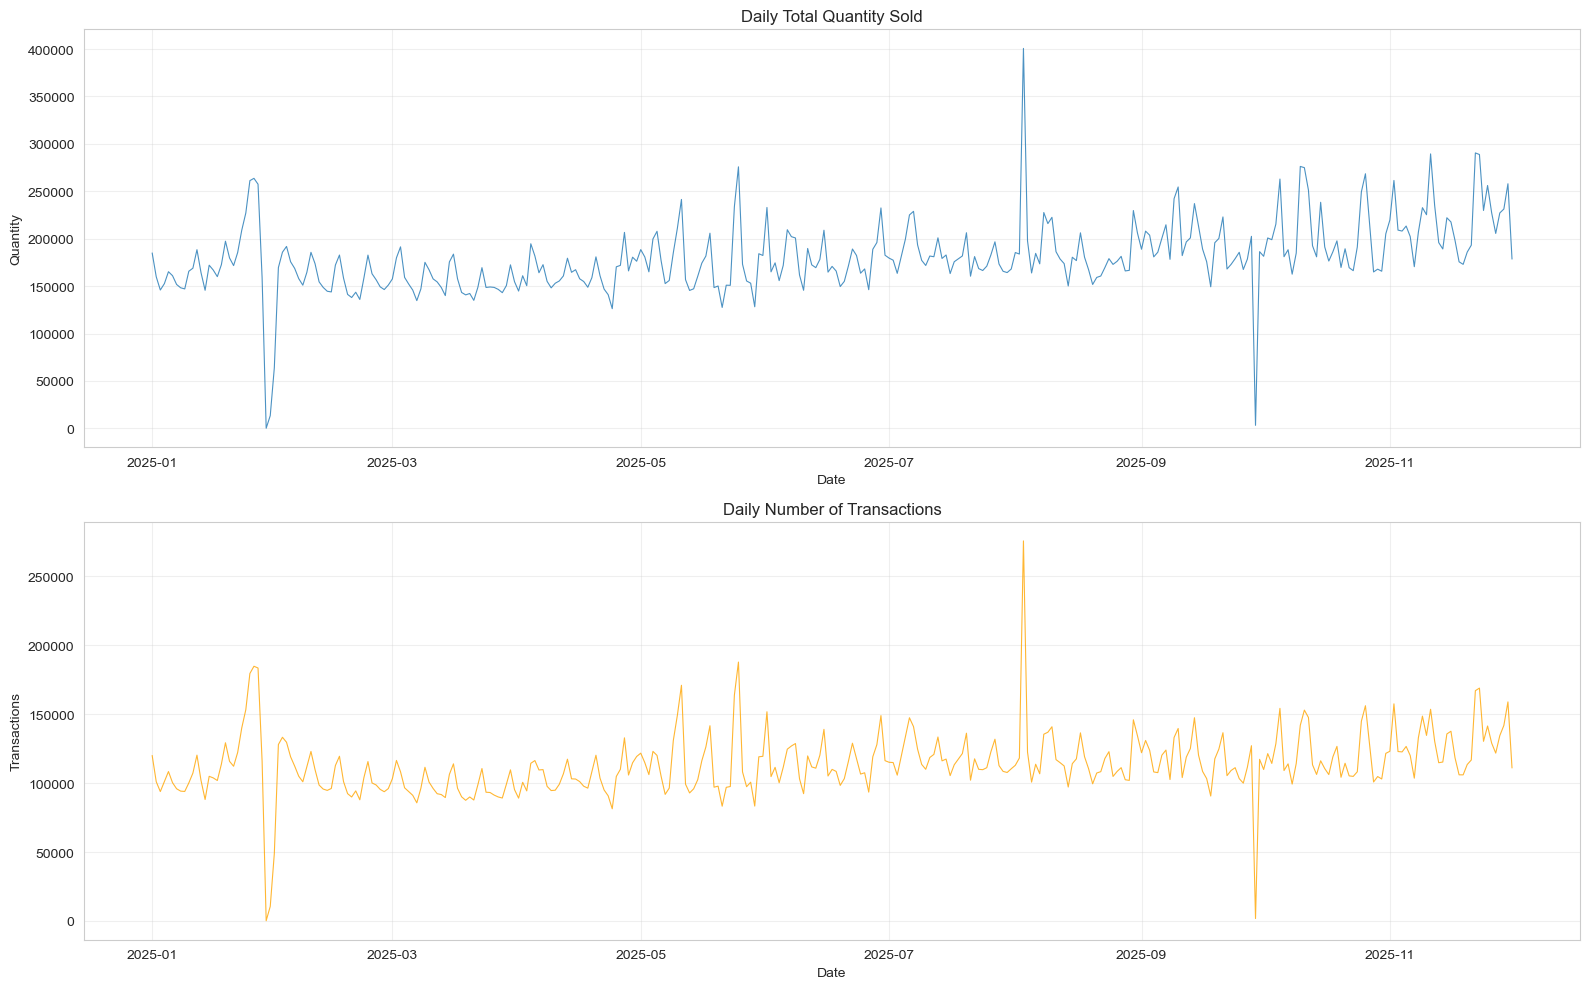

In [4]:
pd_daily = daily_sales.to_pandas()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Total quantity trend
axes[0].plot(pd_daily["date"], pd_daily["total_qty"], linewidth=0.8, alpha=0.8)
axes[0].set_title("Daily Total Quantity Sold")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Quantity")
axes[0].grid(True, alpha=0.3)

# Number of transactions trend
axes[1].plot(pd_daily["date"], pd_daily["num_transactions"], linewidth=0.8, alpha=0.8, color="orange")
axes[1].set_title("Daily Number of Transactions")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Transactions")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Weekday Analysis

### 5.1 Seasonal Indices by Weekday

Compute the ratio of each weekday's average sales to the overall daily average. A value > 1.0 means that weekday sells above average.

In [5]:
overall_avg_qty = daily_sales["total_qty"].mean()
overall_avg_txn = daily_sales["num_transactions"].mean()

weekday_stats = (
    daily_sales
    .group_by(["weekday", "weekday_name"])
    .agg([
        pl.col("total_qty").mean().alias("avg_qty"),
        pl.col("total_qty").median().alias("median_qty"),
        pl.col("total_qty").std().alias("std_qty"),
        pl.col("num_transactions").mean().alias("avg_txn"),
        pl.len().alias("num_days")
    ])
    .sort("weekday")
    .with_columns([
        (pl.col("avg_qty") / overall_avg_qty).alias("qty_seasonal_index"),
        (pl.col("avg_txn") / overall_avg_txn).alias("txn_seasonal_index"),
    ])
)

print(f"Overall daily average quantity: {overall_avg_qty:,.1f}")
print(f"Overall daily average transactions: {overall_avg_txn:,.1f}")
print("\nWeekday Seasonal Indices:")
print(weekday_stats)

Overall daily average quantity: 180,206.2
Overall daily average transactions: 113,508.5

Weekday Seasonal Indices:
shape: (7, 9)
┌─────────┬────────────┬────────────┬───────────┬───┬───────────┬──────────┬───────────┬───────────┐
│ weekday ┆ weekday_na ┆ avg_qty    ┆ median_qt ┆ … ┆ avg_txn   ┆ num_days ┆ qty_seaso ┆ txn_seaso │
│ ---     ┆ me         ┆ ---        ┆ y         ┆   ┆ ---       ┆ ---      ┆ nal_index ┆ nal_index │
│ i8      ┆ ---        ┆ f64        ┆ ---       ┆   ┆ f64       ┆ u32      ┆ ---       ┆ ---       │
│         ┆ str        ┆            ┆ f64       ┆   ┆           ┆          ┆ f64       ┆ f64       │
╞═════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪══════════╪═══════════╪═══════════╡
│ 1       ┆ Mon        ┆ 176442.404 ┆ 173339.0  ┆ … ┆ 109795.63 ┆ 47       ┆ 0.979114  ┆ 0.96729   │
│         ┆            ┆ 255        ┆           ┆   ┆ 8298      ┆          ┆           ┆           │
│ 2       ┆ Tue        ┆ 174127.957 ┆ 170831.0  ┆ … ┆ 108180.68

### 5.2 Weekday Boxplots

C:\Users\Quoc Kien\AppData\Local\Temp\ipykernel_11724\3530252633.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pd_daily, x="weekday_name", y="total_qty", order=weekday_order, ax=axes[0], palette="viridis")
C:\Users\Quoc Kien\AppData\Local\Temp\ipykernel_11724\3530252633.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pd_daily, x="weekday_name", y="num_transactions", order=weekday_order, ax=axes[1], palette="coolwarm")


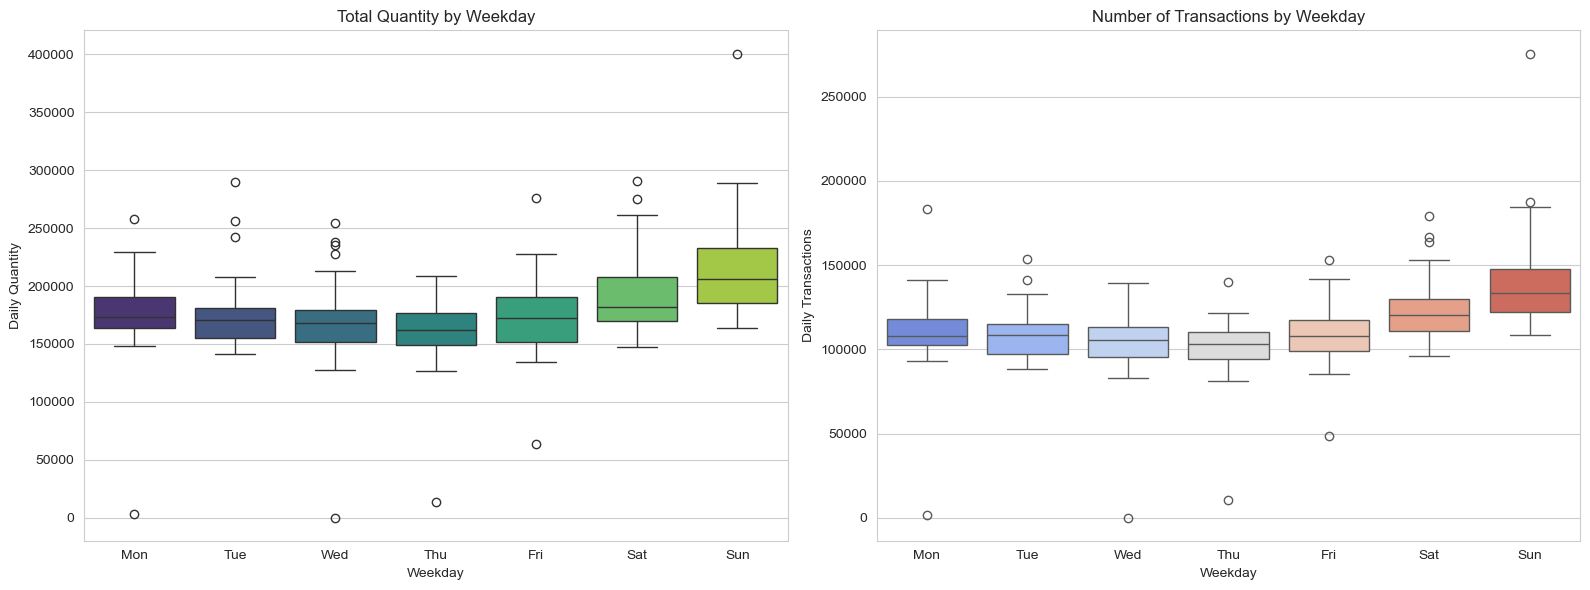

In [6]:
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Quantity boxplot
sns.boxplot(data=pd_daily, x="weekday_name", y="total_qty", order=weekday_order, ax=axes[0], palette="viridis")
axes[0].set_title("Total Quantity by Weekday")
axes[0].set_xlabel("Weekday")
axes[0].set_ylabel("Daily Quantity")

# Transaction count boxplot
sns.boxplot(data=pd_daily, x="weekday_name", y="num_transactions", order=weekday_order, ax=axes[1], palette="coolwarm")
axes[1].set_title("Number of Transactions by Weekday")
axes[1].set_xlabel("Weekday")
axes[1].set_ylabel("Daily Transactions")

plt.tight_layout()
plt.show()

### 5.3 Kruskal-Wallis Test

Since daily sales distributions may be skewed, we use the non-parametric Kruskal-Wallis H-test to determine whether there are statistically significant differences between weekday groups.

In [7]:
# Prepare groups for Kruskal-Wallis
weekday_groups_qty = []
weekday_groups_txn = []
for wd in range(1, 8):
    mask = pd_daily["weekday"] == wd
    weekday_groups_qty.append(pd_daily.loc[mask, "total_qty"].values)
    weekday_groups_txn.append(pd_daily.loc[mask, "num_transactions"].values)

# Kruskal-Wallis for quantity
h_stat_qty, p_val_qty = stats.kruskal(*weekday_groups_qty)
print(f"Kruskal-Wallis (quantity by weekday): H = {h_stat_qty:.2f}, p = {p_val_qty:.6f}")
print(f"  -> {'Significant' if p_val_qty < 0.05 else 'Not significant'} at alpha = 0.05")

# Kruskal-Wallis for transactions
h_stat_txn, p_val_txn = stats.kruskal(*weekday_groups_txn)
print(f"\nKruskal-Wallis (transactions by weekday): H = {h_stat_txn:.2f}, p = {p_val_txn:.6f}")
print(f"  -> {'Significant' if p_val_txn < 0.05 else 'Not significant'} at alpha = 0.05")

Kruskal-Wallis (quantity by weekday): H = 73.44, p = 0.000000
  -> Significant at alpha = 0.05

Kruskal-Wallis (transactions by weekday): H = 106.65, p = 0.000000
  -> Significant at alpha = 0.05


## 6. Monthly Analysis

### 6.1 Monthly Seasonal Indices

In [8]:
monthly_stats = (
    daily_sales
    .group_by("month")
    .agg([
        pl.col("total_qty").sum().alias("total_qty"),
        pl.col("total_qty").mean().alias("avg_daily_qty"),
        pl.col("num_transactions").sum().alias("total_txn"),
        pl.col("num_transactions").mean().alias("avg_daily_txn"),
        pl.len().alias("num_days")
    ])
    .sort("month")
    .with_columns([
        (pl.col("avg_daily_qty") / overall_avg_qty).alias("qty_seasonal_index"),
        (pl.col("avg_daily_txn") / overall_avg_txn).alias("txn_seasonal_index"),
    ])
)

print("Monthly Seasonal Indices:")
print(monthly_stats)

Monthly Seasonal Indices:
shape: (12, 8)
┌───────┬───────────┬─────────────┬───────────┬─────────────┬──────────┬─────────────┬─────────────┐
│ month ┆ total_qty ┆ avg_daily_q ┆ total_txn ┆ avg_daily_t ┆ num_days ┆ qty_seasona ┆ txn_seasona │
│ ---   ┆ ---       ┆ ty          ┆ ---       ┆ xn          ┆ ---      ┆ l_index     ┆ l_index     │
│ i8    ┆ i32       ┆ ---         ┆ u32       ┆ ---         ┆ u32      ┆ ---         ┆ ---         │
│       ┆           ┆ f64         ┆           ┆ f64         ┆          ┆ f64         ┆ f64         │
╞═══════╪═══════════╪═════════════╪═══════════╪═════════════╪══════════╪═════════════╪═════════════╡
│ 1     ┆ 5111048   ┆ 164872.5161 ┆ 3346259   ┆ 107943.8387 ┆ 31       ┆ 0.91491     ┆ 0.950976    │
│       ┆           ┆ 29          ┆           ┆ 1           ┆          ┆             ┆             │
│ 2     ┆ 4496932   ┆ 160604.7142 ┆ 2958962   ┆ 105677.2142 ┆ 28       ┆ 0.891227    ┆ 0.931007    │
│       ┆           ┆ 86          ┆           ┆ 86

### 6.2 Month-by-Weekday Heatmap

Average daily quantity for each (month, weekday) combination.

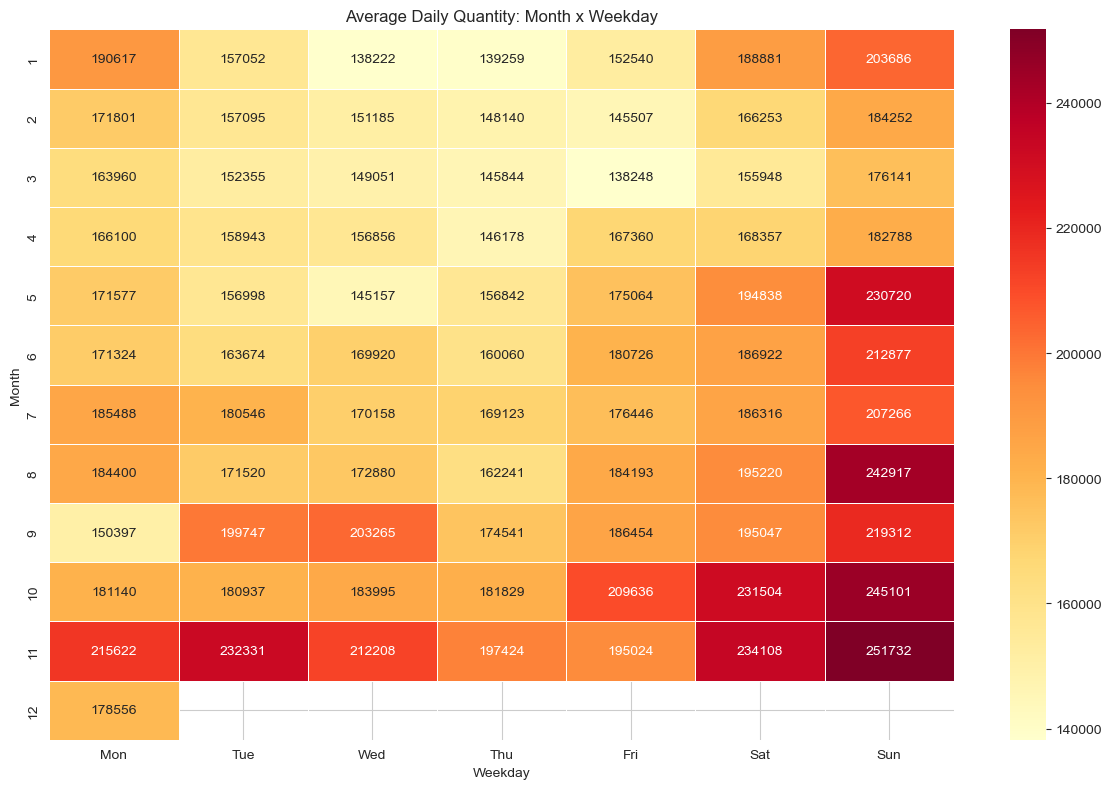

In [9]:
month_weekday = (
    daily_sales
    .group_by(["month", "weekday"])
    .agg(pl.col("total_qty").mean().alias("avg_qty"))
    .sort(["month", "weekday"])
).to_pandas()

# Pivot for heatmap
pivot = month_weekday.pivot(index="month", columns="weekday", values="avg_qty")
pivot.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5)
plt.title("Average Daily Quantity: Month x Weekday")
plt.ylabel("Month")
plt.xlabel("Weekday")
plt.tight_layout()
plt.show()

## 7. Z-Score Outlier Detection

Flag days where the total quantity sold is unusually high or low (|Z| > 2).

In [10]:
std_qty = daily_sales["total_qty"].std()

outlier_days = daily_sales.with_columns(
    ((pl.col("total_qty") - overall_avg_qty) / std_qty).alias("z_score")
).filter(
    pl.col("z_score").abs() > 2
).sort("z_score", descending=True)

print(f"Number of outlier days (|Z| > 2): {len(outlier_days)}")
print("\nTop outlier days (high sales):")
print(outlier_days.filter(pl.col("z_score") > 0).head(10).select(["date", "weekday_name", "total_qty", "z_score"]))

print("\nTop outlier days (low sales):")
print(outlier_days.filter(pl.col("z_score") < 0).sort("z_score").head(10).select(["date", "weekday_name", "total_qty", "z_score"]))

Number of outlier days (|Z| > 2): 19

Top outlier days (high sales):
shape: (10, 4)
┌─────────────────────┬──────────────┬───────────┬──────────┐
│ date                ┆ weekday_name ┆ total_qty ┆ z_score  │
│ ---                 ┆ ---          ┆ ---       ┆ ---      │
│ datetime[μs]        ┆ str          ┆ i32       ┆ f64      │
╞═════════════════════╪══════════════╪═══════════╪══════════╡
│ 2025-08-03 00:00:00 ┆ Sun          ┆ 400682    ┆ 5.849444 │
│ 2025-11-22 00:00:00 ┆ Sat          ┆ 290476    ┆ 2.925568 │
│ 2025-11-11 00:00:00 ┆ Tue          ┆ 289447    ┆ 2.898268 │
│ 2025-11-23 00:00:00 ┆ Sun          ┆ 288792    ┆ 2.88089  │
│ 2025-10-10 00:00:00 ┆ Fri          ┆ 276237    ┆ 2.547793 │
│ 2025-05-25 00:00:00 ┆ Sun          ┆ 275812    ┆ 2.536517 │
│ 2025-10-11 00:00:00 ┆ Sat          ┆ 274947    ┆ 2.513568 │
│ 2025-10-26 00:00:00 ┆ Sun          ┆ 268494    ┆ 2.342363 │
│ 2025-01-26 00:00:00 ┆ Sun          ┆ 263673    ┆ 2.214457 │
│ 2025-10-05 00:00:00 ┆ Sun          ┆ 262925   

### 7.1 Outlier Days Visualization

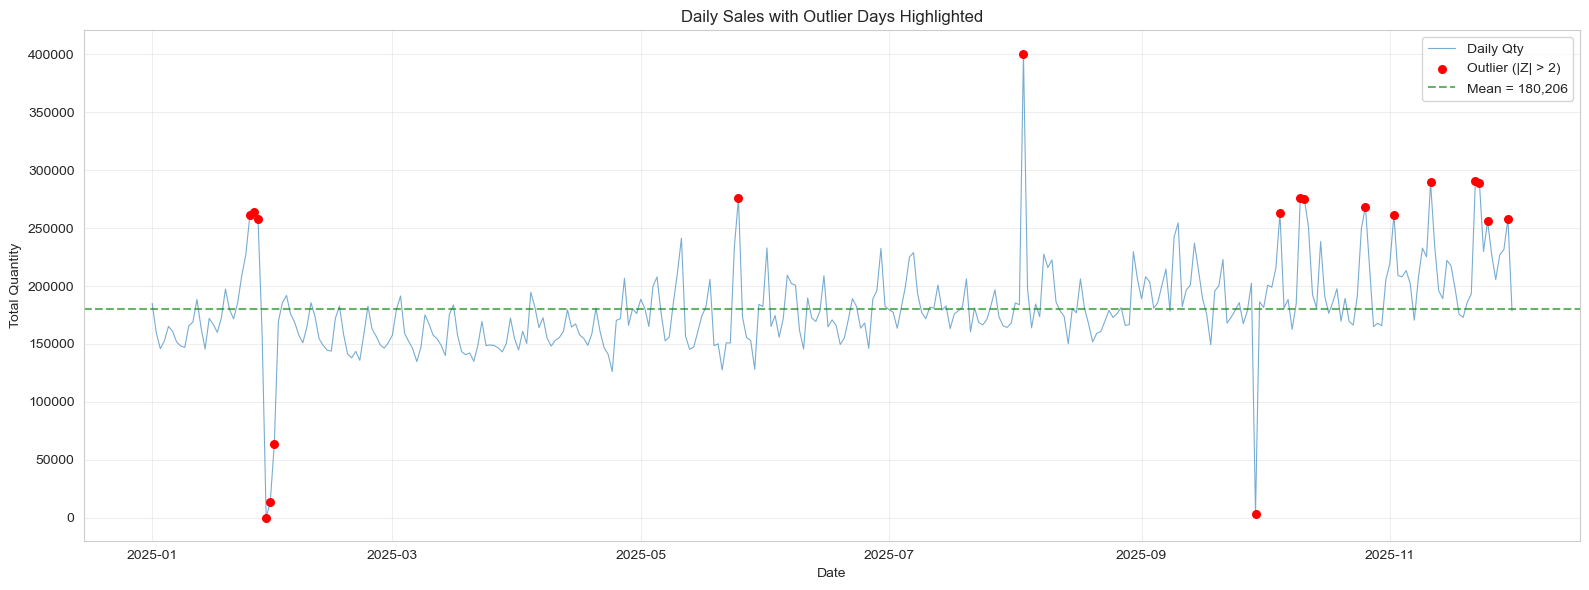

In [11]:
# Plot daily trend with outlier days highlighted
pd_all = daily_sales.with_columns(
    ((pl.col("total_qty") - overall_avg_qty) / std_qty).alias("z_score")
).to_pandas()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(pd_all["date"], pd_all["total_qty"], linewidth=0.8, alpha=0.6, label="Daily Qty")

# Highlight outliers
outlier_mask = pd_all["z_score"].abs() > 2
ax.scatter(
    pd_all.loc[outlier_mask, "date"],
    pd_all.loc[outlier_mask, "total_qty"],
    color="red", s=30, zorder=5, label="Outlier (|Z| > 2)"
)

ax.axhline(y=overall_avg_qty, color="green", linestyle="--", alpha=0.6, label=f"Mean = {overall_avg_qty:,.0f}")
ax.set_title("Daily Sales with Outlier Days Highlighted")
ax.set_xlabel("Date")
ax.set_ylabel("Total Quantity")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Conclusion and Decision

**Decision Rule:** Keep the idea if regular seasonality is strong enough to support timing features or demand planning.

### Summary of Findings

| Metric | Value |
|--------|-------|
| Date range | 332 days |
| Overall daily avg quantity | 180,206.2 |
| Overall daily avg transactions | 113,508.5 |
| Kruskal-Wallis H (qty by weekday) | H = 73.44, **p ≈ 0.000000** → Significant |
| Kruskal-Wallis H (txn by weekday) | H = 106.65, **p ≈ 0.000000** → Significant |
| Highest weekday seasonal index (qty) | **Sunday** — 1.192 |
| Lowest weekday seasonal index (qty) | **Thursday** — 0.899 |
| Highest weekday seasonal index (txn) | **Sunday** — 1.220 |
| Lowest weekday seasonal index (txn) | **Thursday** — 0.895 |
| Highest monthly seasonal index (qty) | **November** — 1.228 |
| Lowest monthly seasonal index (qty) | **March** — 0.863 |
| Outlier days (\|Z\| > 2) | **19 days** |
| Top high-sales outlier | 2025-08-03 (Sun), Z = 5.85 |
| Top low-sales outlier | 2025-01-29 (Wed), Z = −4.78 |

### Interpretation

1. **Weekday seasonality is statistically significant.** The Kruskal-Wallis H-test returns p ≈ 0 for both total quantity and number of transactions, decisively rejecting the null hypothesis of no weekday effect. Sunday consistently leads with a seasonal index ~1.19–1.22×, while Thursday lags at ~0.90×. Saturday also shows elevated activity (~1.06–1.09×). This confirms a strong **weekend effect** that can be directly exploited in replenishment scheduling and staffing decisions.

2. **Monthly seasonality is present and actionable.** November (qty index 1.23) and October (qty index 1.12) are the peak months, likely driven by year-end promotions and holiday shopping. March (qty index 0.86) and February (qty index 0.89) are the weakest. This clear seasonal ramp-up supports advance inventory planning for Q4.

3. **The month-by-weekday heatmap reveals interaction effects.** Peak cells (e.g., November × Sunday at ~290K avg daily qty) are significantly above the overall mean of ~180K, while trough cells (e.g., March × Thursday) fall well below. These interaction effects can feed a richer demand-forecasting model that accounts for both weekly and monthly cycles simultaneously.

4. **Outlier days are explainable.** The extreme high outlier (2025-08-03, Z=5.85, a Sunday) is likely tied to a major promotional event. The cluster of extreme low outliers in late January (2025-01-29 to 2025-01-31) almost certainly corresponds to the **Tết (Lunar New Year) holiday** when operations are shut down or drastically reduced. These patterns are well-understood business events and can be handled by an explicit holiday calendar in any forecasting model.

### Decision

**KEEP — strong seasonality signal across both weekday and monthly dimensions.**

The data provides robust statistical evidence that temporal variables—weekday patterns and monthly fluctuations—offer a meaningful signal for:
- **Replenishment timing:** Stock replenishment should be front-loaded before weekends (especially Sundays) and before the Q4 seasonal ramp.
- **Demand forecasting features:** Weekday-of-week and month-of-year should be included as features in any recommendation or demand-prediction model.
- **Anomaly detection:** A holiday/event calendar combined with Z-score monitoring can flag unusual sales days for investigation, improving forecast accuracy.

This analysis confirms that the purchase seasonality idea transitions from exploration to an actionable input for the project's replenishment logic and personalized recommendation workflows.